Here, we want to check whether precinct order plays a part in the observed regionalism in archetypes.

In [6]:
import sys
sys.path.append('..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tqdm

from scipy.stats import entropy, wasserstein_distance
from scipy.spatial.distance import jensenshannon

from src.config import load_config
from src.data import load_complete
from src.data.preprocessing import preprocess_from_config
from src.unmixing import est_noise, hysime, mvsa, sunsal_mod

sns.set_style('whitegrid')
config = load_config()

In [3]:
def run_pipeline(Y_in, p, seed, verbose=False):
    np.random.seed(seed)
    w_hat, Rw_hat = est_noise(Y_in, noise_type='additive', verbose=False)
    kf, Ek, E, delta_p = hysime(Y_in, w_hat, Rw_hat, verbose=False)
    n_arch = p or kf
    endm, Sest, Up, my, sing_values = mvsa(
        Y_in, p=n_arch,
        MM_iters=config['unmixing'].getint('mvsa_mm_iters'),
        spherize='yes', verbose=0)
    abundances, res_p, res_d = sunsal_mod(
        endm, Y_in, positivity='yes', addone='yes',
        AL_iters=config['unmixing'].getint('sunsal_al_iters'),
        lambda_=0.0, tol=config['unmixing'].getfloat('sunsal_tol'), verbose='no')
    Y_rec = endm @ abundances
    rmse = float(np.sqrt(np.mean((Y_in - Y_rec) ** 2)))
    if verbose:
        print(f'kf={kf}, n_arch={n_arch}, RMSE={rmse:.6f}')
    return {'endm': endm, 'abundances': abundances, 'kf': int(kf),
            'n_arch': int(n_arch), 'rmse': rmse}

In [8]:
SEED = config['unmixing'].getint('seed')
np.random.seed(SEED)

# Number of archetypes
P = config['unmixing'].getint('n_archetypes') or None

df = load_complete(config)

n_trials = 10
results = []

for trial in tqdm.tqdm(range(n_trials)):
    # print(f'Trial {trial + 1}/{n_trials}')
    np.random.seed(SEED + trial)

    pre = preprocess_from_config(df, config)
    Y_raw = pre.Y_raw
    Y = pre.Y
    L, N = Y.shape
    labels = pre.candidate_labels

    results_t = run_pipeline(Y, p=P, seed=SEED + trial, verbose=False)
    results.append(results_t)

  0%|          | 0/10 [00:00<?, ?it/s]

candidates: 66 -> 66 (25th pct >= 1.0)
precincts:  92,488 -> 92,487 (total votes >= 1.0)
Y: 66 candidates x 92,487 precincts (valid_ballots normalization)
SNR estimated = -inf[dB]
... Select the projective proj.


/Users/hannaharjonillo/Documents/UP/PhD Physics/repositories/voting-unmixing-ph/notebooks/../src/unmixing/endmember_extraction.py:259: UserWarning: sparse_svds failed, falling back to full SVD: `k` must be an integer satisfying `0 < k < min(A.shape)`.
  warnings.warn(f"sparse_svds failed, falling back to full SVD: {e}")
/Users/hannaharjonillo/Documents/UP/PhD Physics/repositories/voting-unmixing-ph/notebooks/../src/unmixing/endmember_extraction.py:157: UserWarning: SNR estimation: Denominator or numerator for log10 is non-positive. Returning -inf.
  warnings.warn(
 10%|█         | 1/10 [00:07<01:07,  7.55s/it]

candidates: 66 -> 66 (25th pct >= 1.0)
precincts:  92,488 -> 92,487 (total votes >= 1.0)
Y: 66 candidates x 92,487 precincts (valid_ballots normalization)
SNR estimated = -inf[dB]
... Select the projective proj.


/Users/hannaharjonillo/Documents/UP/PhD Physics/repositories/voting-unmixing-ph/notebooks/../src/unmixing/endmember_extraction.py:259: UserWarning: sparse_svds failed, falling back to full SVD: `k` must be an integer satisfying `0 < k < min(A.shape)`.
  warnings.warn(f"sparse_svds failed, falling back to full SVD: {e}")
/Users/hannaharjonillo/Documents/UP/PhD Physics/repositories/voting-unmixing-ph/notebooks/../src/unmixing/endmember_extraction.py:157: UserWarning: SNR estimation: Denominator or numerator for log10 is non-positive. Returning -inf.
  warnings.warn(
 20%|██        | 2/10 [00:09<00:33,  4.19s/it]

...

/Users/hannaharjonillo/Documents/UP/PhD Physics/repositories/voting-unmixing-ph/notebooks/../src/unmixing/endmember_extraction.py:259: UserWarning: sparse_svds failed, falling back to full SVD: `k` must be an integer satisfying `0 < k < min(A.shape)`.
  warnings.warn(f"sparse_svds failed, falling back to full SVD: {e}")
/Users/hannaharjonillo/Documents/UP/PhD Physics/repositories/voting-unmixing-ph/notebooks/../src/unmixing/endmember_extraction.py:157: UserWarning: SNR estimation: Denominator or numerator for log10 is non-positive. Returning -inf.
  warnings.warn(
 80%|████████  | 8/10 [00:39<00:10,  5.29s/it]

candidates: 66 -> 66 (25th pct >= 1.0)
precincts:  92,488 -> 92,487 (total votes >= 1.0)
Y: 66 candidates x 92,487 precincts (valid_ballots normalization)
SNR estimated = -inf[dB]
... Select the projective proj.


/Users/hannaharjonillo/Documents/UP/PhD Physics/repositories/voting-unmixing-ph/notebooks/../src/unmixing/endmember_extraction.py:259: UserWarning: sparse_svds failed, falling back to full SVD: `k` must be an integer satisfying `0 < k < min(A.shape)`.
  warnings.warn(f"sparse_svds failed, falling back to full SVD: {e}")
/Users/hannaharjonillo/Documents/UP/PhD Physics/repositories/voting-unmixing-ph/notebooks/../src/unmixing/endmember_extraction.py:157: UserWarning: SNR estimation: Denominator or numerator for log10 is non-positive. Returning -inf.
  warnings.warn(
 90%|█████████ | 9/10 [00:43<00:05,  5.08s/it]

candidates: 66 -> 66 (25th pct >= 1.0)
precincts:  92,488 -> 92,487 (total votes >= 1.0)
Y: 66 candidates x 92,487 precincts (valid_ballots normalization)
SNR estimated = -inf[dB]
... Select the projective proj.


/Users/hannaharjonillo/Documents/UP/PhD Physics/repositories/voting-unmixing-ph/notebooks/../src/unmixing/endmember_extraction.py:259: UserWarning: sparse_svds failed, falling back to full SVD: `k` must be an integer satisfying `0 < k < min(A.shape)`.
  warnings.warn(f"sparse_svds failed, falling back to full SVD: {e}")
/Users/hannaharjonillo/Documents/UP/PhD Physics/repositories/voting-unmixing-ph/notebooks/../src/unmixing/endmember_extraction.py:157: UserWarning: SNR estimation: Denominator or numerator for log10 is non-positive. Returning -inf.
  warnings.warn(
100%|██████████| 10/10 [00:46<00:00,  4.69s/it]


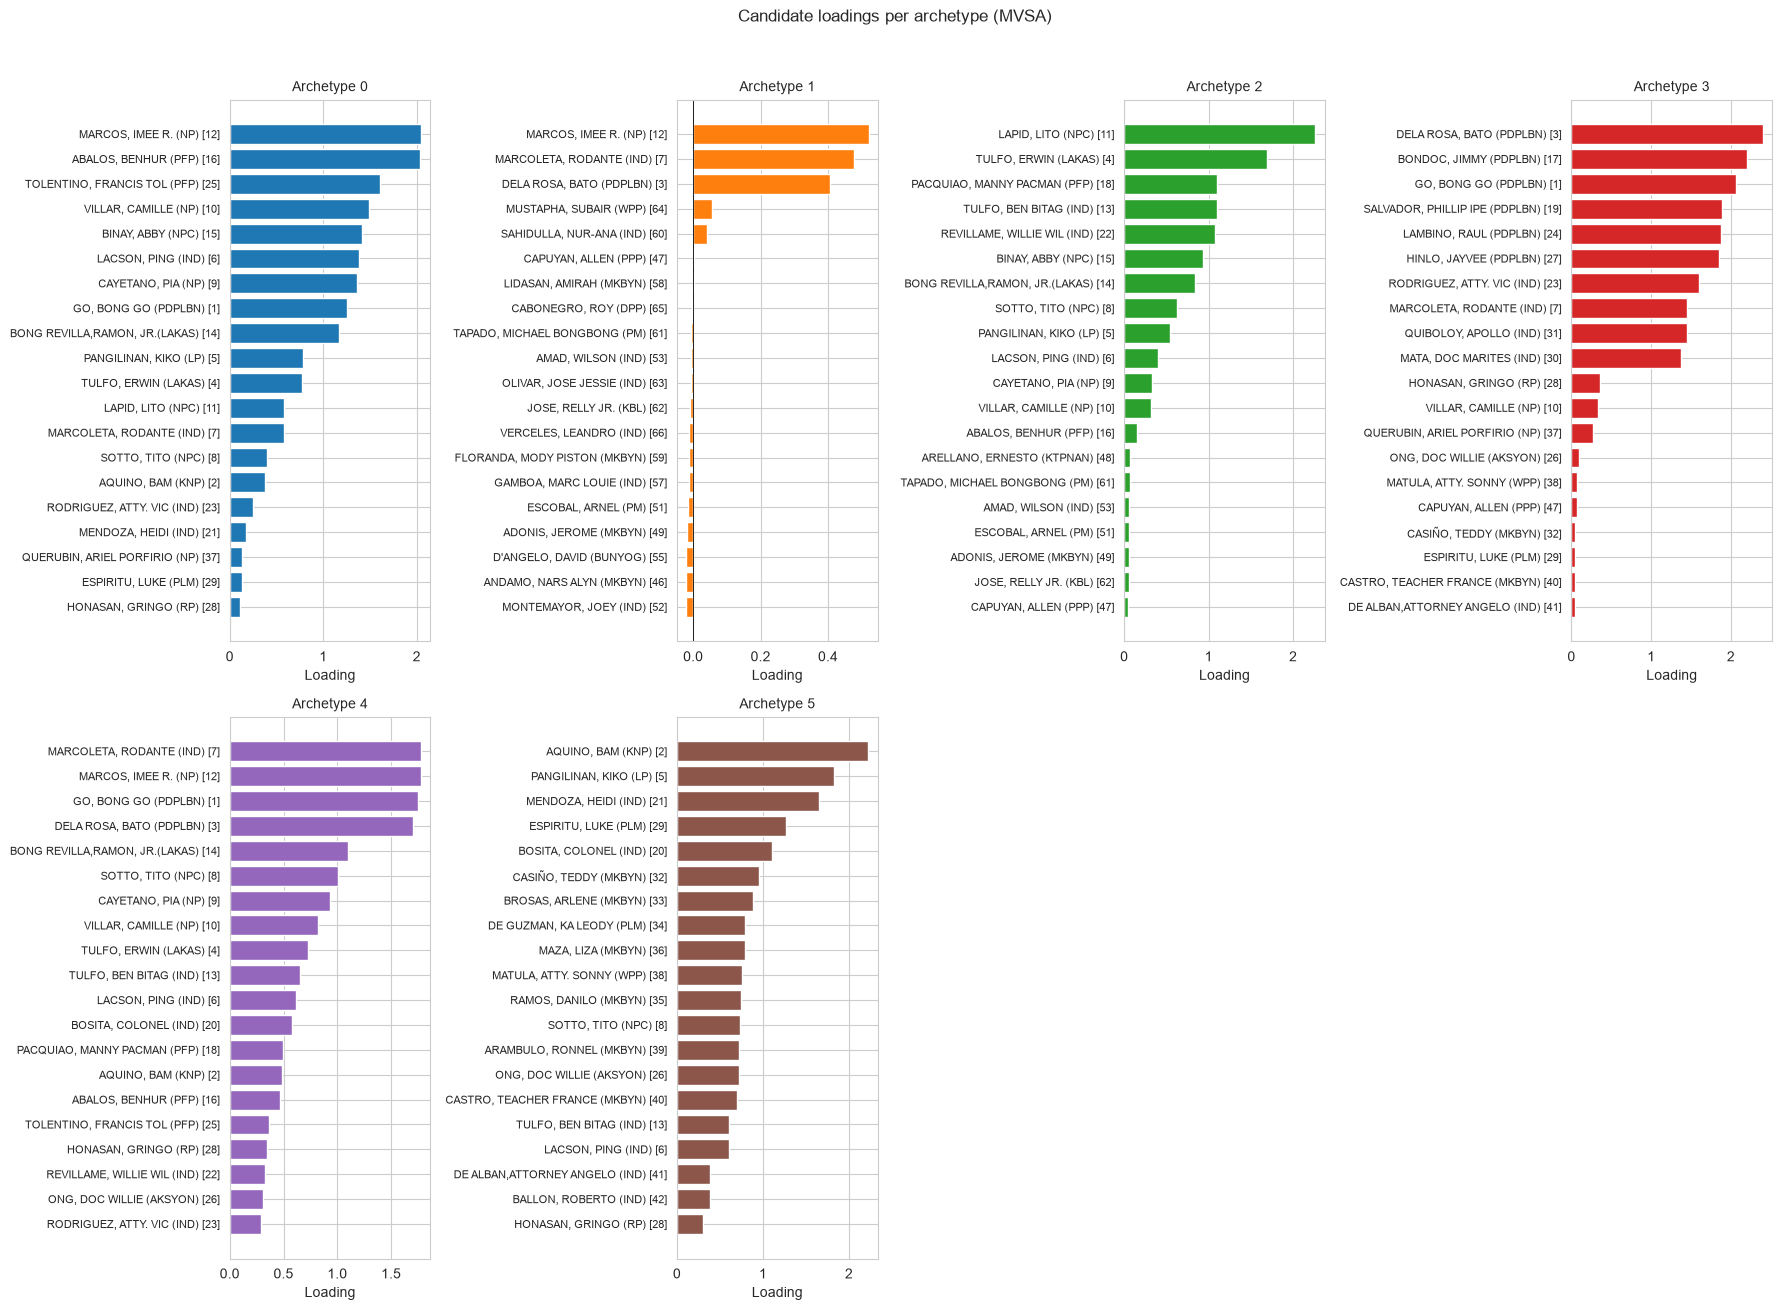

In [14]:
from src.figures import plot_archetypes_loadings_grid

candidate_labels = pre.candidate_labels

plot_archetypes_loadings_grid(results[2]["endm"], candidate_labels, top_n=20,
                              suptitle='Candidate loadings per archetype (MVSA)')